In [ ]:
import pandas as pd
# import locale

# --- 1. Carregar e Limpar Dados de Temperatura (Mirante A701) ---

# Caminho DENTRO DO AMBIENTE COLAB
file_path_temp = '/content/dados_A701_M_2010-01-01_2023-12-30.csv'

skiprows_temp_correto = 10

try:

    df_temp = pd.read_csv(
        file_path_temp,
        sep=';',
        decimal=',',
        skiprows=skiprows_temp_correto,
        encoding='latin-1',
        usecols=[0, 1]
    )


    if len(df_temp.columns) == 2:
        df_temp.columns = ['Data', 'TempMediaC']
        df_temp['Data'] = pd.to_datetime(df_temp['Data'])
        df_temp = df_temp.set_index('Data')

        print("--- Dados de Temperatura (Mirante A701) ---")
        print(df_temp.head())
        print("\nInformações do DataFrame de Temperatura:")
        df_temp.info()
        print("\nValores Ausentes na Temperatura:")
        print(df_temp.isnull().sum())
    else:

        print(f"ERRO INESPERADO: Mesmo com usecols=[0,1], não leu 2 colunas. Encontrou {len(df_temp.columns)}.")
        df_temp = None

except FileNotFoundError:
    print(f"ERRO: Arquivo de temperatura NÃO encontrado em: {file_path_temp}")
    df_temp = None
except Exception as e:
    print(f"ERRO ao carregar/processar arquivo de temperatura: {e}")
    df_temp = None

print("\n" + "="*50 + "\n")

# --- 2. Carregar e Limpar Dados de Saúde (Internações) ---


# Caminho DENTRO DO AMBIENTE COLAB
file_path_saude = '/content/A091020192_29_142_186.csv'
skiprows_saude_correto = 4

try:
    df_saude = pd.read_csv(
        file_path_saude,
        sep=';',
        skiprows=skiprows_saude_correto,
        engine='python',
        encoding='latin-1'
    )

    if len(df_saude.columns) >= 3 :
       df_saude.columns = ['Data_Str', 'Normal', 'Internacoes'] + list(df_saude.columns[3:])
    else:
        print(f"ERRO: Esperava pelo menos 3 colunas no arquivo de saúde, mas encontrou {len(df_saude.columns)}.")
        df_saude_preview = pd.read_csv(file_path_saude, sep=';', skiprows=skiprows_saude_correto, encoding='latin-1', nrows=5)
        print(df_saude_preview)
        raise ValueError("Estrutura de colunas inesperada no arquivo de saúde.")

    mes_map = {
        'Jan': 1, 'Fev': 2, 'Mar': 3, 'Abr': 4, 'Mai': 5, 'Jun': 6,
        'Jul': 7, 'Ago': 8, 'Set': 9, 'Out': 10, 'Nov': 11, 'Dez': 12
    }

    def parse_data_saude(data_str):
        if isinstance(data_str, str) and '/' in data_str:
            try:
                if '(' in data_str:
                    data_str = data_str.split('(')[0].strip()
                mes_str, ano_str = data_str.split('/')
                mes_num = mes_map[mes_str.capitalize()]
                ano_num = int(ano_str)
                return f"{ano_num:04d}-{mes_num:02d}-01"
            except Exception: return None
        return None

    df_saude['Data'] = df_saude['Data_Str'].apply(parse_data_saude)
    df_saude['Data'] = pd.to_datetime(df_saude['Data'])
    df_saude = df_saude.dropna(subset=['Data'])
    df_saude['Internacoes'] = pd.to_numeric(df_saude['Internacoes'], errors='coerce')
    df_saude = df_saude.dropna(subset=['Internacoes'])
    df_saude['Internacoes'] = df_saude['Internacoes'].astype(int)
    df_saude = df_saude[['Data', 'Internacoes']].set_index('Data')

    print("--- Dados de Saúde (Internações) ---")
    print(df_saude.head())
    print("\nInformações do DataFrame de Saúde:")
    df_saude.info()
    print("\nValores Ausentes na Saúde:")
    print(df_saude.isnull().sum())

except FileNotFoundError:
    print(f"ERRO: Arquivo de saúde NÃO encontrado em: {file_path_saude}")
    df_saude = None
except Exception as e:
    print(f"ERRO ao carregar/processar arquivo de saúde: {e}")
    df_saude = None

print("\n" + "="*50 + "\n")

# --- 3. Unir os Dados ---

if df_temp is not None and df_saude is not None:
    df_final = pd.merge(df_temp, df_saude, left_index=True, right_index=True, how='inner')
    df_final = df_final.sort_index()

    print("--- DataFrame Final Combinado (Temperatura + Internações) ---")
    print(df_final.head())
    print("\n")
    print(df_final.tail())
    print("\nInformações do DataFrame Final:")
    df_final.info()
    print("\nValores Ausentes no DataFrame Final:")
    print(df_final.isnull().sum())
else:
    print("Não foi possível unir os DataFrames pois um ou ambos não foram carregados corretamente.")

# 'df_final' está pronto para a próxima fase: Análise Exploratória (EDA)

--- Dados de Temperatura (Mirante A701) ---
            TempMediaC
Data                  
2010-01-31        23.5
2010-02-28        24.5
2010-03-31        22.7
2010-04-30        20.4
2010-05-31        18.3

Informações do DataFrame de Temperatura:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 2010-01-31 to 2023-12-31
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TempMediaC  168 non-null    float64
dtypes: float64(1)
memory usage: 2.6 KB

Valores Ausentes na Temperatura:
TempMediaC    0
dtype: int64


--- Dados de Saúde (Internações) ---
            Internacoes
Data                   
2010-01-01          170
2010-02-01          127
2010-03-01          190
2010-04-01          211
2010-05-01          196

Informações do DataFrame de Saúde:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 2010-01-01 to 2023-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtyp


--- Verificando df_final ANTES da Etapa 1 da EDA (Plot) ---
df_final existe e NÃO está vazio. Informações:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 2010-01-01 to 2023-12-01
Freq: MS
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TempMediaC   168 non-null    float64
 1   Internacoes  168 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.9 KB

Primeiras linhas:
            TempMediaC  Internacoes
Data                               
2010-01-01        23.5          170
2010-02-01        24.5          127
2010-03-01        22.7          190
2010-04-01        20.4          211
2010-05-01        18.3          196

Valores Ausentes:
TempMediaC     0
Internacoes    0
dtype: int64

--- Iniciando Plots da Etapa 1 da EDA ---


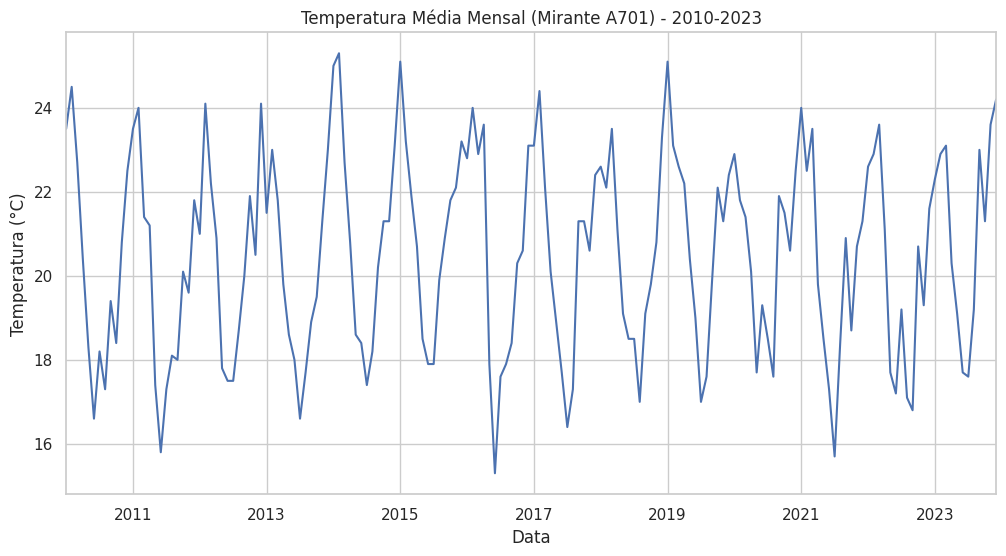

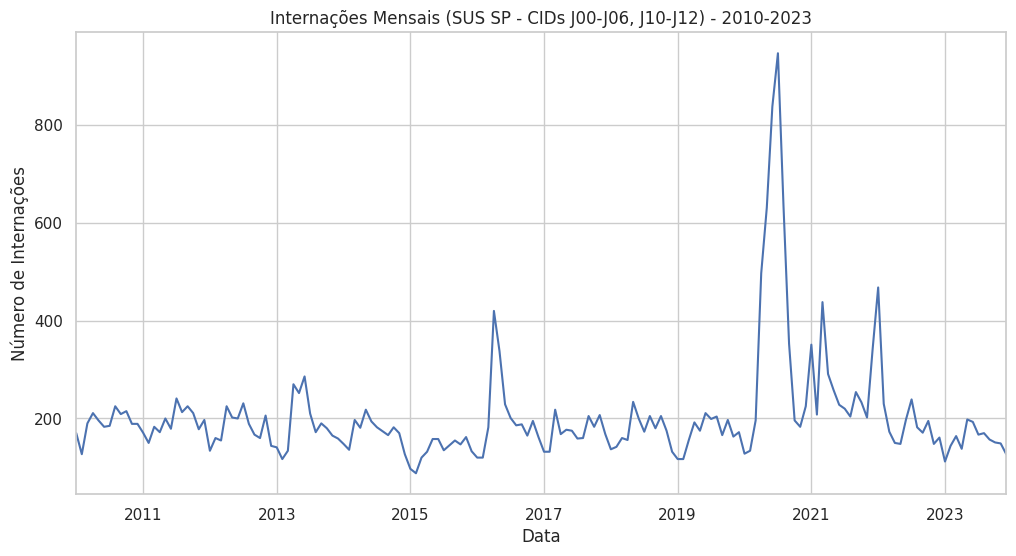

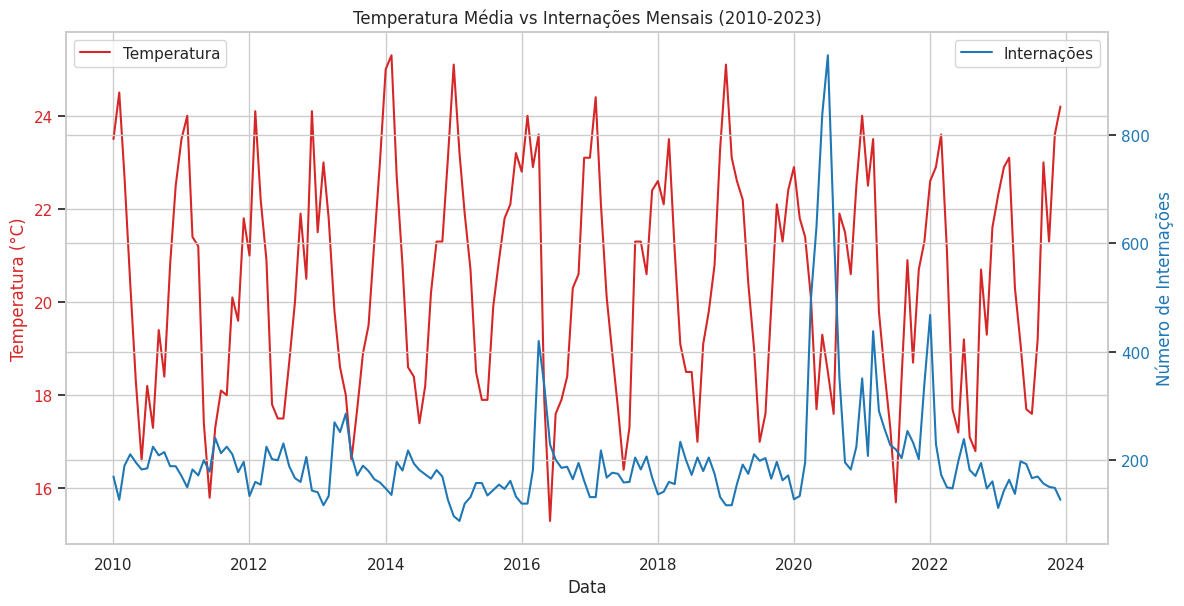

--- Fim da Etapa 1 da EDA ---


In [ ]:
# --- 1. Visualização Básica das Séries Temporais (COM VERIFICAÇÃO INICIAL) ---

import matplotlib.pyplot as plt
import seaborn as sns

# Define um estilo visual melhor para os gráficos
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ****** VERIFICAÇÃO IMEDIATAMENTE ANTES DE PLOTAR ******
print("\n--- Verificando df_final ANTES da Etapa 1 da EDA (Plot) ---")
try:
    if df_final is not None and not df_final.empty:
        print("df_final existe e NÃO está vazio. Informações:")
        df_final.info()
        print("\nPrimeiras linhas:")
        print(df_final.head())
        print("\nValores Ausentes:")
        print(df_final.isnull().sum())
        # Prossegue para plotar
        print("\n--- Iniciando Plots da Etapa 1 da EDA ---")

        # Plot da Temperatura Média Mensal
        plt.figure()
        df_final['TempMediaC'].plot(title='Temperatura Média Mensal (Mirante A701) - 2010-2023')
        plt.xlabel('Data')
        plt.ylabel('Temperatura (°C)')
        plt.show()

        # Plot das Internações Mensais
        plt.figure()
        df_final['Internacoes'].plot(title='Internações Mensais (SUS SP - CIDs J00-J06, J10-J12) - 2010-2023')
        plt.xlabel('Data')
        plt.ylabel('Número de Internações')
        plt.show()

        # Plot de ambas as séries juntas (com eixos Y separados)
        fig, ax1 = plt.subplots()
        color = 'tab:red'
        ax1.set_xlabel('Data')
        ax1.set_ylabel('Temperatura (°C)', color=color)
        ax1.plot(df_final.index, df_final['TempMediaC'], color=color, label='Temperatura')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')
        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Número de Internações', color=color)
        ax2.plot(df_final.index, df_final['Internacoes'], color=color, label='Internações')
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.legend(loc='upper right')
        fig.tight_layout()
        plt.title('Temperatura Média vs Internações Mensais (2010-2023)')
        plt.show()

    elif df_final is None:
         print("ERRO GRAVE: A variável 'df_final' é None neste ponto. Verifique a célula da Etapa 3.")
    else: # df_final existe mas está vazio
         print("ERRO GRAVE: A variável 'df_final' existe, mas está VAZIA neste ponto. Verifique a célula da Etapa 3.")
         print(df_final.info())

except NameError:
    print("ERRO GRAVE: A variável 'df_final' não foi definida antes desta célula. Execute a célula da Etapa 3.")
except Exception as e:
    print(f"ERRO inesperado ao tentar plotar ou verificar df_final: {e}")

print("--- Fim da Etapa 1 da EDA ---")


--- 2. Análise de Sazonalidade ---


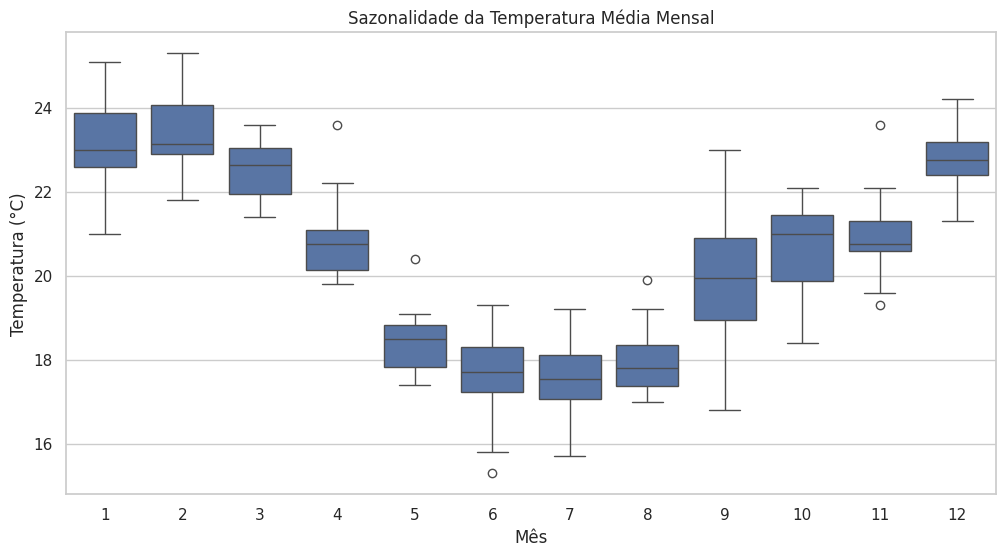

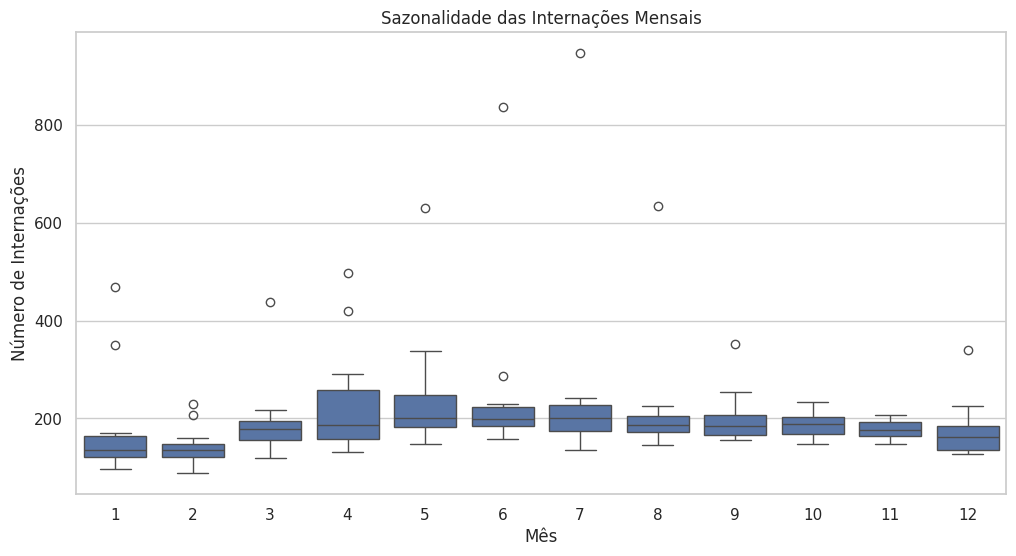

In [ ]:
# --- 2. Análise de Sazonalidade (Boxplots Mensais) ---

print("\n--- 2. Análise de Sazonalidade ---")

# Criar colunas de Ano e Mês para facilitar a agregação
df_final['Ano'] = df_final.index.year
df_final['Mes'] = df_final.index.month

# Boxplot para Temperatura por Mês
plt.figure()
sns.boxplot(x='Mes', y='TempMediaC', data=df_final)
plt.title('Sazonalidade da Temperatura Média Mensal')
plt.xlabel('Mês')
plt.ylabel('Temperatura (°C)')
plt.show()

# Boxplot para Internações por Mês
plt.figure()
sns.boxplot(x='Mes', y='Internacoes', data=df_final)
plt.title('Sazonalidade das Internações Mensais')
plt.xlabel('Mês')
plt.ylabel('Número de Internações')
plt.show()

In [ ]:
# --- 3. Unir os Dados (COM CORREÇÃO DE RESAMPLE E VERIFICAÇÃO FINAL) ---

df_final = None # Reseta df_final no início desta célula

# Verifica se os dataframes de origem existem e não são None
if df_temp is not None and df_saude is not None:

    print("--- Iniciando Etapa 3: Unir os Dados ---")
    # print(" índices Originais (Primeiras 5 datas):")
    # print("df_temp:", df_temp.index[:5])
    # print("df_saude:", df_saude.index[:5])

    # ****** ETAPA DE CORREÇÃO: Resample para início do mês ('MS') ******
    try:
        df_temp_resampled = df_temp.resample('MS').first()
        df_saude_resampled = df_saude.resample('MS').first()

        # print("\n índices Após Resample para 'MS' (Primeiras 5 datas):") # Já verificado antes
        # print("df_temp_resampled:", df_temp_resampled.index[:5])
        # print("df_saude_resampled:", df_saude_resampled.index[:5])

        # Agora faz o merge com os índices alinhados
        df_final_merge = pd.merge(df_temp_resampled, df_saude_resampled,
                                  left_index=True, right_index=True, how='inner')

        df_final_merge = df_final_merge.sort_index() # Garante ordenação por data

        # ****** VERIFICAÇÃO IMEDIATAMENTE APÓS O MERGE ******
        print("\n--- Verificando Resultado do Merge (df_final_merge) ---")
        if df_final_merge is not None and not df_final_merge.empty:
            print("Merge SUCESSO! Primeiras linhas:")
            print(df_final_merge.head())
            print("\nInformações:")
            df_final_merge.info()
            print("\nValores Ausentes:")
            print(df_final_merge.isnull().sum())
            df_final = df_final_merge # Atribui à variável principal SE deu certo
        else:
            print("FALHA no Merge! O DataFrame resultante está vazio ou é None.")
            print("Verifique os dataframes resampleados e a lógica do merge.")
            df_final = None

    except Exception as e:
        print(f"\nERRO durante o resample ou merge na Etapa 3: {e}")
        df_final = None

else:
    print("Não foi possível iniciar a Etapa 3 (Unir os Dados) pois df_temp ou df_saude não foram carregados corretamente nas etapas anteriores.")
    df_final = None

print("--- Fim da Etapa 3 ---")

--- Iniciando Etapa 3: Unir os Dados ---

--- Verificando Resultado do Merge (df_final_merge) ---
Merge SUCESSO! Primeiras linhas:
            TempMediaC  Internacoes
Data                               
2010-01-01        23.5          170
2010-02-01        24.5          127
2010-03-01        22.7          190
2010-04-01        20.4          211
2010-05-01        18.3          196

Informações:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 2010-01-01 to 2023-12-01
Freq: MS
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TempMediaC   168 non-null    float64
 1   Internacoes  168 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.9 KB

Valores Ausentes:
TempMediaC     0
Internacoes    0
dtype: int64
--- Fim da Etapa 3 ---


In [ ]:
# --- 4. Teste de Estacionariedade (Teste Dickey-Fuller Aumentado - ADF) ---
# Hipótese Nula (H0): A série NÃO é estacionária (possui raiz unitária)
# Hipótese Alternativa (H1): A série é estacionária

print("\n--- 4. Teste de Estacionariedade (ADF) ---")

def teste_adf(serie, nome_serie):
    """Realiza o teste ADF e imprime os resultados formatados."""
    print(f"\nResultados do Teste Dickey-Fuller Aumentado para '{nome_serie}':")
    result = adfuller(serie.dropna()) # dropna() para o caso de diferenciação
    print(f'Estatística do Teste ADF: {result[0]:.4f}')
    print(f'Valor-p: {result[1]:.4f}')
    print('Valores Críticos:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')

    if result[1] <= 0.05:
        print(f"-> Conclusão: Rejeitamos a hipótese nula (p={result[1]:.4f} <= 0.05). A série '{nome_serie}' é provavelmente ESTACIONÁRIA.")
    else:
        print(f"-> Conclusão: Não podemos rejeitar a hipótese nula (p={result[1]:.4f} > 0.05). A série '{nome_serie}' é provavelmente NÃO ESTACIONÁRIA.")

# Testar a série original de Temperatura
teste_adf(df_final['TempMediaC'], 'Temperatura Média')

# Testar a série original de Internações
teste_adf(df_final['Internacoes'], 'Internações')



--- 4. Teste de Estacionariedade (ADF) ---

Resultados do Teste Dickey-Fuller Aumentado para 'Temperatura Média':
Estatística do Teste ADF: -2.4489
Valor-p: 0.1284
Valores Críticos:
	1%: -3.4730
	5%: -2.8803
	10%: -2.5767
-> Conclusão: Não podemos rejeitar a hipótese nula (p=0.1284 > 0.05). A série 'Temperatura Média' é provavelmente NÃO ESTACIONÁRIA.

Resultados do Teste Dickey-Fuller Aumentado para 'Internações':
Estatística do Teste ADF: -5.7593
Valor-p: 0.0000
Valores Críticos:
	1%: -3.4706
	5%: -2.8792
	10%: -2.5762
-> Conclusão: Rejeitamos a hipótese nula (p=0.0000 <= 0.05). A série 'Internações' é provavelmente ESTACIONÁRIA.



--- Análise de Correlação Cruzada (CCF) ---


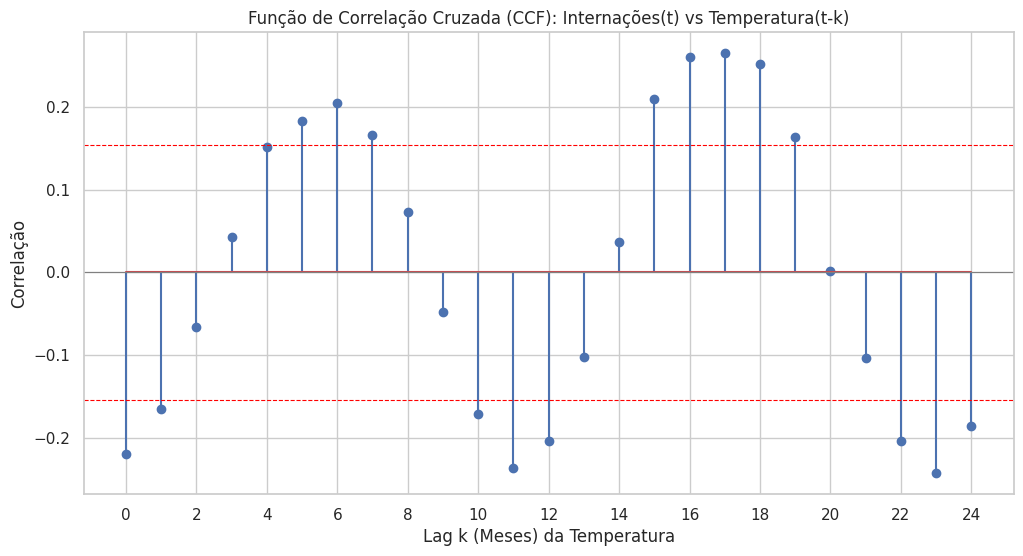


Interpretação CCF (lags >= 0):
Lag 0: Correlação entre Internações(t) e Temperatura(t) = -0.2192
Maior correlação (absoluta) ocorre no Lag 17 com valor 0.2652
Lag k: Correlação entre Internações(t) e Temperatura(t-k)
(Linhas pontilhadas vermelhas indicam o intervalo de confiança aproximado para significância estatística)


In [ ]:
# (O cálculo da correlação de Pearson e o scatter plot antes disto permanecem iguais)
# ...

# Análise de Correlação Cruzada (CCF)
# Mostra a correlação da Temperatura em lags (meses anteriores) com as Internações atuais
print("\n--- Análise de Correlação Cruzada (CCF) ---")

try:
    # Calcula a CCF. y=Internacoes, x=TempMediaC
    max_lags = 24 # Analisar até 24 meses de defasagem
    ccf_values = sm.tsa.stattools.ccf(df_final['Internacoes'], df_final['TempMediaC'], adjusted=False)

    plt.figure()
    # ****** CORREÇÃO: Removido use_line_collection=True ******
    plt.stem(range(max_lags + 1), ccf_values[:max_lags+1]) # Plota os lags >= 0
    plt.title('Função de Correlação Cruzada (CCF): Internações(t) vs Temperatura(t-k)')
    plt.xlabel('Lag k (Meses) da Temperatura')
    plt.ylabel('Correlação')
    plt.axhline(0, color='grey', linewidth=0.8) # Linha no zero para referência
    # Linhas de significância (aproximadas, +/- 2/sqrt(N)) - Opcional
    n_obs = len(df_final)
    conf_int = 2 / (n_obs**0.5)
    plt.axhline(conf_int, color='red', linestyle='--', linewidth=0.8)
    plt.axhline(-conf_int, color='red', linestyle='--', linewidth=0.8)

    plt.xticks(range(0, max_lags + 1, 2))
    plt.grid(True)
    plt.show()

    print(f"\nInterpretação CCF (lags >= 0):")
    print(f"Lag 0: Correlação entre Internações(t) e Temperatura(t) = {ccf_values[0]:.4f}")
    # Encontra o lag com a maior correlação (em valor absoluto, excluindo lag 0 se desejado)
    if len(ccf_values) > 1:
       max_corr_lag = max(range(1, min(len(ccf_values), max_lags + 1)), key=lambda k: abs(ccf_values[k]))
       print(f"Maior correlação (absoluta) ocorre no Lag {max_corr_lag} com valor {ccf_values[max_corr_lag]:.4f}")
    print(f"Lag k: Correlação entre Internações(t) e Temperatura(t-k)")
    print("(Linhas pontilhadas vermelhas indicam o intervalo de confiança aproximado para significância estatística)")


except Exception as e:
    print(f"\nErro ao calcular ou plotar CCF: {e}")